**Preparing Datasets**

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
# print(tf.__version__)

In [6]:
train_dir = "dataset/train"
test_dir = "dataset/test"

In [7]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(128, 128),
    batch_size=32
)

Found 8381 files belonging to 3 classes.


In [8]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(128, 128),
    batch_size=32
)

Found 201 files belonging to 3 classes.


In [9]:
class_names = train_dataset.class_names
print(class_names)

['non_recyclable', 'organic', 'recyclable']


In [10]:
normalization_layer = layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))

In [11]:
# for images, labels in train_dataset.take(1):
#     print(images.shape)
#     print(labels.shape)
# print(class_names)
# print(images.shape)

**Building the CNN model**

In [12]:
model = models.Sequential([
    
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    
    layers.Dense(128, activation='relu'),
    
    layers.Dense(3, activation='softmax')
])
# model.summary()

c:\Users\abc\Documents\vs-py\waste-segregation\venv312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**Train the model**

In [14]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)

Epoch 1/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 108s 400ms/step - accuracy: 0.7951 - loss: 0.5106 - val_accuracy: 0.8259 - val_loss: 0.4769
Epoch 2/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 105s 397ms/step - accuracy: 0.8707 - loss: 0.3223 - val_accuracy: 0.8557 - val_loss: 0.4162
Epoch 3/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 103s 393ms/step - accuracy: 0.9142 - loss: 0.2247 - val_accuracy: 0.7612 - val_loss: 0.5843
Epoch 4/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 106s 404ms/step - accuracy: 0.9470 - loss: 0.1462 - val_accuracy: 0.8358 - val_loss: 0.6291
Epoch 5/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 105s 398ms/step - accuracy: 0.9656 - loss: 0.0978 - val_accuracy: 0.7811 - val_loss: 0.7003
Epoch 6/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 107s 408ms/step - accuracy: 0.9773 - loss: 0.0640 - val_accuracy: 0.8806 - val_loss: 0.5448
Epoch 7/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 110s 418ms/step - accuracy: 0.9878 - loss: 0.0378 - val_accuracy: 0.7164 - val_loss: 0.9901
Epoch 8/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 112s 425ms/step - accuracy: 0.9887 -

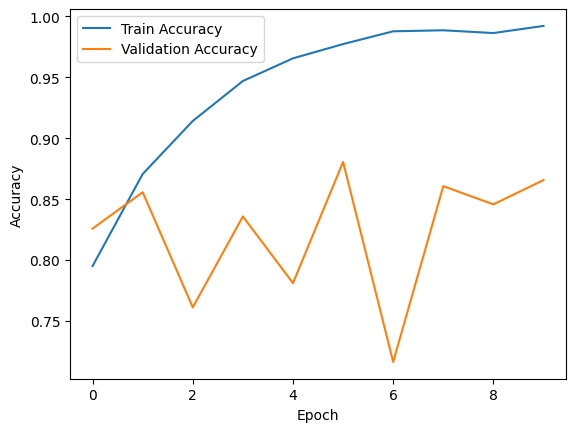

In [15]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

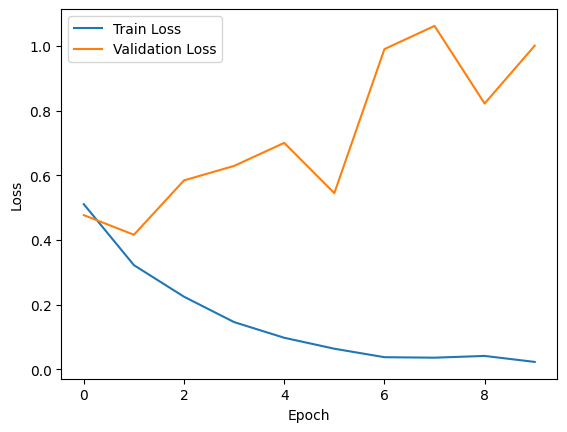

In [16]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [17]:
test_loss, test_accuracy = model.evaluate(test_dataset)
print("Test Accuracy:", test_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 636ms/step - accuracy: 0.8657 - loss: 1.0008
Test Accuracy: 0.8656716346740723


In [19]:
model.save("model/waste_classifier.h5")